In [1]:
import numpy as np
import matplotlib.pyplot as plt
import verde as vd
import harmonica as hm
import boule as bl
from numpy.linalg import inv
import spherical as sph

In [2]:
ellipsoid = bl.WGS84

region = [-5,5,-5,5]

coordinates = vd.grid_coordinates(region=region, shape=(40,40), extra_coords= ellipsoid.mean_radius)

dipoles = vd.scatter_points(region= (-1,1,-1,1), size=1, extra_coords= ellipsoid.mean_radius - 5e4)

magnetic_moments_observed = (
    np.full((1, 1), 0.0e9),  
    np.full((1, 1), 0.0e9),        
    np.full((1, 1), 1.0e9)       
)

longitude, sph_latitude, radius_obs = tuple(c.ravel() for c in coordinates)

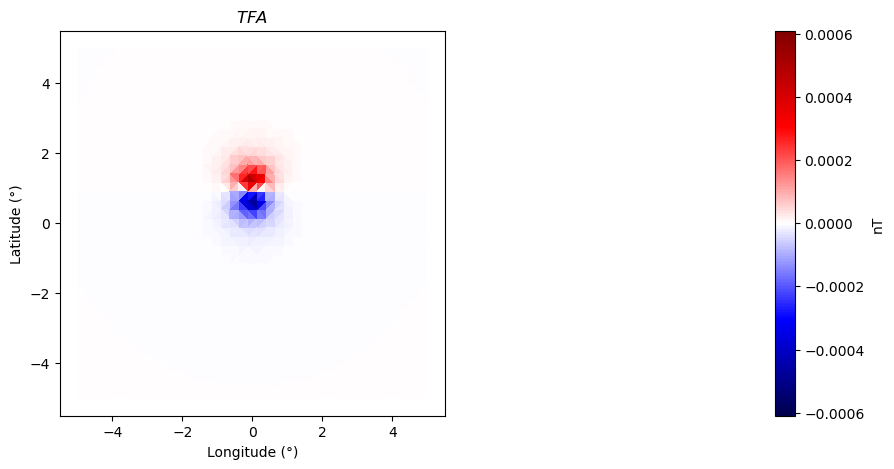

In [6]:
b_observed = sph.foward_modeling_spherical(coordinates, dipoles, magnetic_moments_observed)
observed_data = hm.total_field_anomaly(b_observed, 0, 0)


scale = vd.maxabs(observed_data)

plt.figure(figsize=(15, 5))
plt.tripcolor(longitude, sph_latitude, observed_data, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('$TFA$')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")
plt.show()

In [14]:
def jacobian(coordinates, dipoles, inclination_source, declination_souce, inclination_field, declination_field):

    coordinates = tuple(c.ravel() for c in coordinates)
    dipoles = tuple(d.ravel() for d in dipoles)

    n = coordinates[0].size
    m = dipoles[0].size

    A = np.zeros((n,m))

    magnetic_moment = hm.magnetic_angles_to_vec(np.array([1]), np.array([inclination_source]), np.array([declination_souce]))

    for j in range(m):
        dipole = (dipoles[0][j],dipoles[1][j],dipoles[2][j])
        b_field = sph.foward_modeling_spherical(coordinates,dipole,magnetic_moment)
        A[:,j] = hm.total_field_anomaly(b_field, inclination_field, declination_field)

    return A

In [15]:
equivalent_layer = tuple(c.ravel() for c in vd.grid_coordinates(region= region, shape= (40,40), extra_coords= ellipsoid.mean_radius - 5e5))



A = jacobian(coordinates, equivalent_layer, 0, 0, 0, 0)

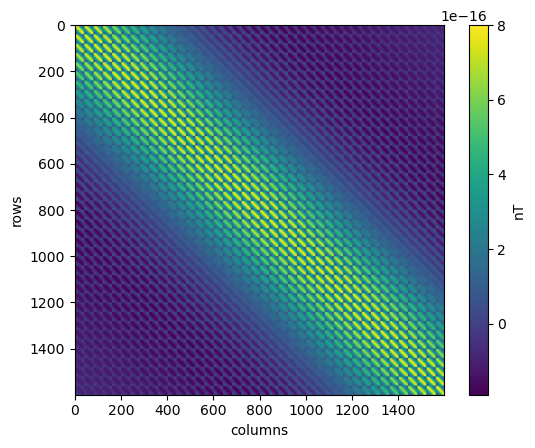

In [16]:
plt.figure()
plt.imshow(A)
plt.colorbar(label="nT")
plt.xlabel("columns")
plt.ylabel("rows")
plt.show()

In [17]:
def calculate_coefficients(observed_data, A, damping):
    
    I = np.identity(A.shape[1]) # needs to = m x m
    # np.shape(A) = A.shape
    
    # The @ operator can be used for conventional matrix multiplication.
    system_matrix = A.T @ A + I * damping
    system_rhs_vector = A.T @ observed_data
    
    coefficients = np.linalg.solve(system_matrix, system_rhs_vector)
    
    return coefficients

In [18]:
damping = 1e-30

coefficients = calculate_coefficients(observed_data, A, damping)

In [27]:
# Make the coordinates of a regular grid
grid_coord = vd.grid_coordinates(region, shape=(100,100), extra_coords=ellipsoid.mean_radius -200)

In [29]:
grid_data = np.zeros(np.shape(grid_coord[0]))

m = equivalent_layer[0].size

magnetic_moment_foward = hm.magnetic_angles_to_vec(np.array([1]), np.array([0]), np.array([0]))

for j in range(m):
    dipole_foward = (dipoles[0][j],dipoles[1][j],dipoles[2][j])
    b_foward = sph.foward_modeling_spherical(grid_coord,dipole_foward,magnetic_moment_foward)
    grid_data += coefficients[j] * hm.total_field_anomaly(b_foward, 0, 0)

IndexError: index 1 is out of bounds for axis 0 with size 1